In [10]:

# # ============================================================
# # CELL 1: Install all dependencies (2026 latest versions)
# # ============================================================

# # Core LangChain ecosystem
# %pip install langchain
# %pip install langchain-community
# %pip install langchain-neo4j       # Official Neo4j LangChain integration
# %pip install langchain-openai
# %pip install langchain-experimental  # LLMGraphTransformer
# %pip install langgraph             # Agentic workflow engine

# # Graph Database
# %pip install neo4j>=5.27.0                   # Neo4j Python driver

# # PDF Processing
# %pip install pymupdf>=1.25.0                 # Fast PDF loader (fitz)
# %pip install pypdf>=4.0.0                    # Alternative PDF loader
# %pip install unstructured[all-docs]  # Layout-aware parsing

# # Graph Visualization
# %pip install yfiles_jupyter_graphs           # Interactive graph in Jupyter
# %pip install networkx                 # Graph algorithms

# # Evaluation
# %pip install ragas                   # RAG evaluation
# %pip install deepeval                # LLM evaluation

# # Utilities
# %pip install python-dotenv
# %pip install tiktoken
# %pip install json-repair
# %pip install tqdm

# print("✅ All dependencies installed successfully")

####  Section 1: Environment Setup & Library Installation

In [11]:
import os
from dotenv import load_dotenv


os.environ["NEO4J_URI"]      = os.getenv("NEO4J_URI")
os.environ["NEO4J_USERNAME"] = os.getenv("NEO4J_USERNAME")
os.environ["NEO4J_PASSWORD"] = os.getenv("NEO4J_PASSWORD")

PDF_PATH = r"F:\sourab\graph-rag\data\Understanding_Climate_Change.pdf"
CHUNK_SIZE     = 500
CHUNK_OVERLAP  = 100
EMBED_MODEL    = "text-embedding-3-small" 
LLM_EXTRACT    = "gpt-4o"
LLM_GENERATE    = "gpt-4o"
VECTOR_INDEX   = "pdf_vector_index"
NODE_LABEL     = "Chunk"

print("✅ Configuration loaded")
print(f"   PDF:           {PDF_PATH}")
print(f"   Neo4j URI:     {os.environ['NEO4J_URI']}")
print(f"   Embed Model:   {EMBED_MODEL}")
print(f"   LLM Extract:   {LLM_EXTRACT}")
print(f"   LLM Generate:  {LLM_GENERATE}")

✅ Configuration loaded
   PDF:           F:\sourab\graph-rag\data\Understanding_Climate_Change.pdf
   Neo4j URI:     bolt://localhost:7687
   Embed Model:   text-embedding-3-small
   LLM Extract:   gpt-4o
   LLM Generate:  gpt-4o


#### 📁 Section 2: PDF Loading & Document Processing

In [12]:
! uv pip install pymupdf

Audited 1 package in 125ms


In [13]:
from langchain_community.document_loaders.pdf import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

PDF_PATH = PDF_PATH
print(f"Loading PDF: {PDF_PATH}")
loader = PyMuPDFLoader(PDF_PATH)
raw_documents = loader.load()

print(f"✅ Loaded {len(raw_documents)} pages from PDF")
print(f"   Sample snippet: {raw_documents[0].page_content[:200]}...")

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", ". ", " ", ""],
    length_function=len,
)
documents = text_splitter.split_documents(raw_documents)
print(f"✅ Split into {len(documents)} chunks")
print(f"   Average chunk length: {sum(len(d.page_content) for d in documents) // len(documents)} chars")

Loading PDF: F:\sourab\graph-rag\data\Understanding_Climate_Change.pdf
✅ Loaded 33 pages from PDF
   Sample snippet: Understanding Climate Change 
Chapter 1: Introduction to Climate Change 
Climate change refers to significant, long-term changes in the global climate. The term 
"global climate" encompasses the plane...
✅ Split into 201 chunks
   Average chunk length: 429 chars


#### 🕸️ Section 3: Knowledge Graph Construction

In [14]:
from langchain_neo4j import Neo4jGraph
graph = Neo4jGraph(
    url=os.environ["NEO4J_URI"],
    username=os.environ["NEO4J_USERNAME"],
    password=os.environ["NEO4J_PASSWORD"],
    enhanced_schema=True,
    sanitize=True,
    refresh_schema=True
)

print("✅ Connected to Neo4j")
print("Graph Schema:")
print(graph.schema)

✅ Connected to Neo4j
Graph Schema:
Node properties:
- **Person**
  - `age`: INTEGER Min: 28, Max: 35
  - `name`: STRING Example: "Alice"
  - `role`: STRING Available options: ['Data Scientist', 'Engineer', 'Designer']
- **Movie**
  - `genre`: STRING Available options: ['Sci-Fi']
  - `rating`: FLOAT Min: 8.7, Max: 8.7
  - `title`: STRING Example: "The Matrix"
  - `year`: INTEGER Min: 1999, Max: 1999
  - `id`: STRING Example: "1"
  - `released`: DATE Min: 1964-12-16, Max: 1996-09-15
  - `imdbRating`: FLOAT Min: 2.4, Max: 9.3
- **Genre**
  - `name`: STRING Example: "Adventure"
Relationship properties:
- **WATCHED**
  - `rating`: INTEGER Min: 5, Max: 5
  - `watched_on`: STRING Available options: ['2024-01-15']
- **KNOWS**
  - `since`: INTEGER Min: 2020, Max: 2020
The relationships:
(:Person)-[:WATCHED]->(:Movie)
(:Person)-[:KNOWS]->(:Person)
(:Person)-[:DIRECTED]->(:Movie)
(:Person)-[:ACTED_IN]->(:Movie)
(:Movie)-[:IN_GENRE]->(:Genre)


#### Entity & Relationship Extraction with LLMGraphTransformer

In [18]:
import warnings
warnings.filterwarnings("ignore", message=".*Pydantic serializer warnings.*")
from langchain_experimental.graph_transformers import LLMGraphTransformer
from langchain_openai import AzureChatOpenAI

llm_extractor = AzureChatOpenAI(
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    azure_deployment=os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME"),
    api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    temperature=0
)
graph_transformer = LLMGraphTransformer(
    llm=llm_extractor,
    allowed_nodes=[
        "Concept",
        "Phenomenon",
        "Substance",
        "Process",
        "Technology",
        "Ecosystem",
        "Organization",
        "Location",
    ],
    allowed_relationships=[
        "CAUSES",
        "CONTRIBUTES_TO",
        "LEADS_TO",
        "IMPACTS",
        "EMITS",
        "ABSORBS",
        "MITIGATES",
        "PART_OF",
        "LOCATED_IN",
        "RELATED_TO"
    ],
    relationship_properties=["confidence"],
    strict_mode=False
)

#### For Async Processing Only

In [20]:
import warnings
warnings.filterwarnings("ignore", message=".*Pydantic serializer warnings.*")
import asyncio
import nest_asyncio
from tqdm.auto import tqdm

nest_asyncio.apply()

BATCH_SIZE = 5
MAX_CONCURRENT = 3    # ← Tune this: higher = faster but more rate-limit risk
all_graph_docs = []

async def extract_graph_async(documents):
    semaphore = asyncio.Semaphore(MAX_CONCURRENT)
    batches = [documents[i:i+BATCH_SIZE] for i in range(0,len(documents), BATCH_SIZE)]
    pbar = tqdm(total=len(batches), desc="Extracting graph (async)")

    async def process_batch(batch):
        async with semaphore:
            result = await graph_transformer.aconvert_to_graph_documents(batch)
            pbar.update(1)
            return result
    
    results = await asyncio.gather(
        *[process_batch(batch)for batch in batches]
    )
    pbar.close()

    all_docs, errors = [],0
    for i, result in enumerate(results):
        if isinstance(result, Exception):
            print(f"⚠️   Batch {i} failed: {result}")
            errors +=1
        else:
            all_docs.extend(result)

    if errors:
        print(f"⚠️   {errors}/{len(batches)} batches failed — check rate limits or reduce MAX_CONCURRENT")

    return all_docs
all_graph_docs = asyncio.run(extract_graph_async(documents))


Extracting graph (async):   0%|          | 0/41 [00:00<?, ?it/s]

In [24]:
print(len(all_graph_docs))

201


In [22]:
all_graph_docs[0].nodes[:5]

[Node(id='Climate Change', type='Concept', properties={}),
 Node(id='Global Climate', type='Concept', properties={}),
 Node(id='Burning Of Fossil Fuels', type='Process', properties={}),
 Node(id='Deforestation', type='Process', properties={})]

In [23]:
all_graph_docs[0].relationships[:5]

[Relationship(source=Node(id='Climate Change', type='Concept', properties={}), target=Node(id='Global Climate', type='Concept', properties={}), type='RELATED_TO', properties={}),
 Relationship(source=Node(id='Burning Of Fossil Fuels', type='Process', properties={}), target=Node(id='Climate Change', type='Concept', properties={}), type='CONTRIBUTES_TO', properties={}),
 Relationship(source=Node(id='Deforestation', type='Process', properties={}), target=Node(id='Climate Change', type='Concept', properties={}), type='CONTRIBUTES_TO', properties={})]

In [25]:
graph.add_graph_documents(
    all_graph_docs,
    baseEntityLabel=True,
    include_source=True
)
graph.refresh_schema()

graph.query("""
    CREATE FULLTEXT INDEX entity_fulltext IF NOT EXISTS
    FOR (n:__Entity__) ON EACH [n.id]
""")
graph.query("CREATE INDEX entity_id IF NOT EXISTS FOR (n:__Entity__) ON (n.id)")
graph.query("CREATE INDEX chunk_text IF NOT EXISTS FOR (n:Document) ON (n.text)")

print("✅ Graph stored in Neo4j")
print("✅ Full-text index 'entity_fulltext' created (required by GraphRetriever)")
print("Updated schema:")
print(graph.schema)

# Quick stats
node_count = graph.query("MATCH (n) RETURN count(n) as nodes")[0]['nodes']
rel_count  = graph.query("MATCH ()-[r]->() RETURN count(r) as rels")[0]['rels']
print(f"\n📊 Graph Stats: {node_count} nodes, {rel_count} relationships")

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The query used a deprecated procedure. ('apoc.create.addLabels' has been replaced by 'Cypher's dynamic labels; `SET n:$(labels)`.')} {position: line: 1, column: 257, offset: 256} for query: "MERGE (d:Document {id:$document.metadata.id}) SET d.text = $document.page_content SET d += $document.metadata WITH d UNWIND $data AS row MERGE (source:`__Entity__` {id: row.id}) SET source += row.properties MERGE (d)-[:MENTIONS]->(source) WITH source, row CALL apoc.create.addLabels( source, [row.type] ) YIELD node RETURN distinct 'done' AS result"
Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future ve

✅ Graph stored in Neo4j
✅ Full-text index 'entity_fulltext' created (required by GraphRetriever)
Updated schema:
Node properties:
- **Person**
  - `age`: INTEGER Min: 28, Max: 35
  - `name`: STRING Example: "Alice"
  - `role`: STRING Available options: ['Data Scientist', 'Engineer', 'Designer']
- **Movie**
  - `genre`: STRING Available options: ['Sci-Fi']
  - `rating`: FLOAT Min: 8.7, Max: 8.7
  - `title`: STRING Example: "The Matrix"
  - `year`: INTEGER Min: 1999, Max: 1999
  - `id`: STRING Example: "1"
  - `released`: DATE Min: 1964-12-16, Max: 1996-09-15
  - `imdbRating`: FLOAT Min: 2.4, Max: 9.3
- **Genre**
  - `name`: STRING Example: "Adventure"
- **Document**
  - `title`: STRING Available options: ['']
  - `id`: STRING Example: "8a075c1b9645a3574f75780e645dabee"
  - `text`: STRING Example: "Understanding Climate Change  Chapter 1: Introduct"
  - `file_path`: STRING Available options: ['F:\\sourab\\graph-rag\\data\\Understanding_Climate_Cha']
  - `creator`: STRING Available option

#### 🔍 Section 4: Vector Index Setup (Hybrid Retrieval)

In [27]:
from langchain_neo4j import Neo4jVector
from langchain_openai import AzureOpenAIEmbeddings

embeddings = AzureOpenAIEmbeddings(
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    azure_deployment=os.getenv("AZURE_OPENAI_EMBEDDING_DEPLOYMENT_NAME"),
    api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
)
vector_index = Neo4jVector.from_existing_graph(
    embedding=embeddings,
    search_type="hybrid",
    node_label="Document",
    text_node_properties=["text"],
    embedding_node_property="embedding", 
    index_name=VECTOR_INDEX,
    keyword_index_name="pdf_keyword_index",
    url=os.environ["NEO4J_URI"],
    username=os.environ["NEO4J_USERNAME"],
    password=os.environ["NEO4J_PASSWORD"]
)
print("✅ Neo4j hybrid vector index created")
print(f"   Index name: {VECTOR_INDEX}")
print(f"   Search type: hybrid (vector + BM25 keyword)")

test_results = vector_index.similarity_search("test query", k=2)
print(f"   Test search returned {len(test_results)} results")


✅ Neo4j hybrid vector index created
   Index name: pdf_vector_index
   Search type: hybrid (vector + BM25 keyword)


Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The query used a deprecated procedure. ('db.index.vector.queryNodes' has been replaced by 'SEARCH')} {position: line: 1, column: 11, offset: 10} for query: "CALL () { CALL db.index.vector.queryNodes($index, $k * $ef, $embedding) YIELD node, score WITH node, score LIMIT $k WITH collect({node:node, score:score}) AS nodes, max(score) AS max UNWIND nodes AS n RETURN n.node AS node, (n.score / max) AS score UNION CALL db.index.fulltext.queryNodes($keyword_index, $query, {limit: $k}) YIELD node, score WITH collect({node:node, score:score}) AS nodes, max(score) AS max UNWIND nodes AS n RETURN n.node AS node, (n.score / max) AS score } WITH node, max(score) AS score ORDER BY score DESC LIMIT $k RETURN reduce(str='', k IN ['text'] | str + '\\n' + k + ': ' + 

   Test search returned 2 results


#### Graph Retriever (Structured Traversal)

In [28]:
from langchain_neo4j import Neo4jGraph
from langchain.schema import BaseRetriever, Document
from typing import List
import json

class GraphRetriever(BaseRetriever):
    """Custom graph retriever: Entity recognition → Cypher traversal → Context"""
    graph: Neo4jGraph
    llm: AzureChatOpenAI
    hops: int = 2

    def _get_relevant_documents(self, query: str)-> List[Document]:
        entity_extraction_prompt = f"""
        Extract the key entities (people, organizations, concepts, technologies) 
        from this question as a JSON list of strings.
        Question: {query}
        Response (JSON list only): 
        """
        entities_raw = self.llm.invoke(entity_extraction_prompt).content
        try:
            entities=self.json.loads(entities_raw)
        except:
            entities = [query]

        results = []
        for entity in entities[:5]:
            cypher="""
            CALL db.index.fulltext.queryNodes('entity_fulltext', $entity)
            YIELD node, score
            WHERE score > 0.5
            WITH node LIMIT 3
            MATCH path = (node)-[*1..{hops}]-(neighbor)
            RETURN 
                node.id as entity,
                collect(DISTINCT neighbor.id) as neighbors,
                collect(DISTINCT type(relationships(path)[0])) as rel_types
            LIMIT 10
            """.format(hops=self.hops)

            try:
                rows = self.graph.query(cypher,  {"entity": entity})
                for row in rows:
                    context =  f"Entity: {row['entity']}\n"
                    context += f"Connected to: {', '.join(row['neighbors'][:10])}\n"
                    context += f"Via relationships: {', '.join(set(row['rel_types']))}"
                    results.append(Document(page_content=context,
                                            metadata={"source": "graph", "entity": row['entity']}))
            except Exception as e:
                print(f"  Graph retrieval warning: {e}")
        return results
        
llm_generator = AzureChatOpenAI(
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    azure_deployment=os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME"),
    api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
)
graph_retriever = GraphRetriever(graph=graph, llm=llm_generator, hops=2)
print("✅ Graph retriever initialized")

✅ Graph retriever initialized


In [29]:
from langchain.retrievers import EnsembleRetriever
vector_retriever = vector_index.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5}
)
ensemble_retriever = EnsembleRetriever(
    retrievers=[graph_retriever, vector_retriever],
    weights=[0.6,0.4]
)
print("✅ EnsembleRetriever configured")
print("   Graph weight:  60% (structural reasoning)")
print("   Vector weight: 40% (semantic similarity)")

✅ EnsembleRetriever configured
   Graph weight:  60% (structural reasoning)
   Vector weight: 40% (semantic similarity)


#### LangGraph State Machine with Conditional Routing

✅ LangGraph GraphRAG workflow compiled
   Routing logic:
     'simple'     → vector_retrieve → generate
     'relational' → graph_retrieve  → generate
     'complex'    → hybrid_retrieve → generate


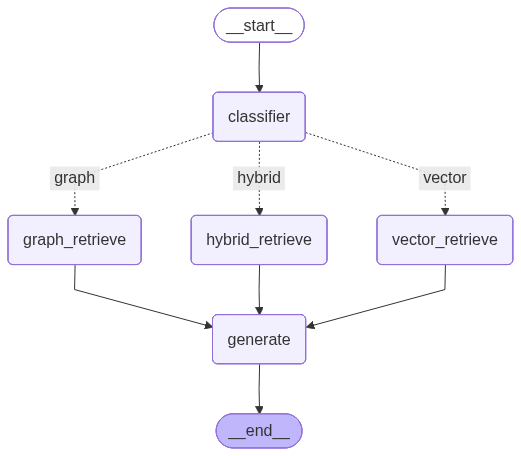

In [34]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List, Literal
from langchain_core.messages import BaseMessage

from IPython.display import Image, display
import operator

class GraphRAGState(TypedDict):
    query: str
    query_type: str
    retrieved_docs: List[str]
    cypher_query: str
    graph_results: str
    final_answer: str
    messages: Annotated[List[BaseMessage],operator.add]

def classify_query(state: GraphRAGState)-> GraphRAGState:
    """Classify query as simple (vector) or complex/relational (graph)."""
    query = state['query']
    classification_prompt = f"""
    Classify this query into ONE category:
    - 'simple': direct fact lookup, definition, simple question
    - 'relational': asks about relationships, connections, 'how X relates to Y'
    - 'complex': multi-hop, thematic, requires traversing multiple concepts
    
    Query: {query}
    Category (one word only):
    """
    result = llm_generator.invoke(classification_prompt).content.strip().lower()
    return {**state, "query_type": result if result in  ['simple','relational','complex'] else 'simple'}

def vector_retrieval_node(state: GraphRAGState)-> GraphRAGState:
    """Standard vector similarity search path."""
    docs = vector_retriever.get_relevant_documents(state['query'])
    retrieved = [d.page_content for d in docs]
    return {**state, "retrieved_docs": retrieved}

def graph_retrieval_node(state: GraphRAGState)-> GraphRAGState:
    """Graph traversal retrieval path with Cypher generation."""
    cyper_prompt = f"""
    You are an expert Neo4j Cypher query generator.
    
    Graph Schema:
    {graph.schema}
    
    Generate a Cypher query to answer this question.
    Use MATCH patterns, traverse 1-3 hops, RETURN relevant context.
    Return ONLY the Cypher query, no explanation.
    
    Question: {state['query']}
    Cypher:
    """
    cyper = llm_generator.invoke(cyper_prompt).content.strip()

    try:
        graph_results = graph.query(cyper)
        result_str = str(graph_results[:20])
    except Exception as e:
        result_str = f"Graph query failed: {e}. Falling back to vector search."
        docs = vector_retriever.get_relevant_documents(state["query"])
        result_str += "\n" + "\n".join([d.page_content for d in docs])
    return {**state, "cypher_query":cyper, "graph_results": result_str}

def hybrid_retrieval_node(state: GraphRAGState)-> GraphRAGState:
    """Hybrid path: ensemble graph + vector retrieval."""
    docs = ensemble_retriever.get_relevant_documents(state['query'])
    retrieved = [d.page_content for d in docs]
    return {**state, "retrieved_docs": retrieved}

def generate_answer(state: GraphRAGState)-> GraphRAGState:
    """Final answer generation with retrieved context."""
    context_text = []
    if state.get("retrieved_docs"):
        context_text.append("## Vector + Graph Retrieved Context:\n"+
                            "\n--\n".join(state["retrieved_docs"]))
    
    if state.get("graph_results"):
        context_text.append("## Structured Graph Context:\n" + state["graph_results"])

    context = "\n\n".join(context_text)

    answer_prompt = f"""
    You are a helpful AI assistant with access to a knowledge graph and document index.
    Answer the question using ONLY the provided context.
    If the context doesn't contain the answer, say so explicitly.
    Cite your sources when possible.
    
    Context:
    {context}
    
    Question: {state['query']}
    
    Answer:
    """
    answer = llm_generator.invoke(answer_prompt).content
    return {**state, "final_answer": answer}

def route_query(state: GraphRAGState)-> Literal["vector", "graph", "hybrid"]:
    query_type = state.get("query_type","simple")
    if query_type == "simple":
        return "vector"
    elif query_type == "relational":
        return "graph"
    else:
        return "hybrid"
    

workflow = StateGraph(GraphRAGState)
workflow.add_node("classifier",      classify_query)
workflow.add_node("vector_retrieve", vector_retrieval_node)
workflow.add_node("graph_retrieve",  graph_retrieval_node)
workflow.add_node("hybrid_retrieve", hybrid_retrieval_node)
workflow.add_node("generate",        generate_answer)

workflow.set_entry_point("classifier")
workflow.add_conditional_edges(
    "classifier",
    route_query,
    {
        "vector": "vector_retrieve",
        "graph":  "graph_retrieve",
        "hybrid": "hybrid_retrieve",
    }
)
workflow.add_edge("vector_retrieve", "generate")
workflow.add_edge("graph_retrieve",  "generate")
workflow.add_edge("hybrid_retrieve", "generate")
workflow.add_edge("generate", END)

graphrag_app = workflow.compile()

print("✅ LangGraph GraphRAG workflow compiled")
print("   Routing logic:")
print("     'simple'     → vector_retrieve → generate")
print("     'relational' → graph_retrieve  → generate")
print("     'complex'    → hybrid_retrieve → generate")

display(Image(graphrag_app.get_graph().draw_mermaid_png()))


#### 💬 Section 6: Querying the GraphRAG System

In [35]:
import warnings
warnings.filterwarnings("ignore")

def ask_graphrag(question: str, verbose: bool=True)->str:
    """Main query interface for the GraphRAG system."""
    print(f"\n{'='*60}")
    print(f"❓ Question: {question}")
    print(f"{'='*60}")

    result = graphrag_app.invoke({
        "query":question,
        "query_type":"",
        "retrieved_docs":[],
        "cypher_query":"",
        "graph_results":"",
        "final_answer":"",
        "messages":[],
    })
    if verbose:
        print(f"\n🔀 Routing:   '{result['query_type']}' path selected")
        if result.get('cypher_query'):
            print(f"\n📊 Cypher:    {result['cypher_query'][:200]}...")
        print(f"\n✅ Answer:\n{result['final_answer']}")
    return result['final_answer']

# Simple vector query
answer1 = ask_graphrag("What are Hydrogen Fuel Cells?")

# Relational/graph query
answer2 = ask_graphrag("How are the impacts of climate change?")

# Complex hybrid query
answer3 = ask_graphrag("What is Agroforestry?")


❓ Question: What are Hydrogen Fuel Cells?


Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The query used a deprecated procedure. ('db.index.vector.queryNodes' has been replaced by 'SEARCH')} {position: line: 1, column: 11, offset: 10} for query: "CALL () { CALL db.index.vector.queryNodes($index, $k * $ef, $embedding) YIELD node, score WITH node, score LIMIT $k WITH collect({node:node, score:score}) AS nodes, max(score) AS max UNWIND nodes AS n RETURN n.node AS node, (n.score / max) AS score UNION CALL db.index.fulltext.queryNodes($keyword_index, $query, {limit: $k}) YIELD node, score WITH collect({node:node, score:score}) AS nodes, max(score) AS max UNWIND nodes AS n RETURN n.node AS node, (n.score / max) AS score } WITH node, max(score) AS score ORDER BY score DESC LIMIT $k RETURN reduce(str='', k IN ['text'] | str + '\\n' + k + ': ' + 


🔀 Routing:   'simple' path selected

✅ Answer:
Hydrogen fuel cells are devices that generate electricity by combining hydrogen with oxygen, producing only water as a byproduct. They offer a clean and sustainable alternative to conventional energy sources, especially for applications like heavy-duty vehicles such as trucks and buses. Developing a robust hydrogen infrastructure is essential for the success of hydrogen fuel cell technologies. 

Cited sources:
- "Hydrogen Fuel Cells Generate electricity by combining hydrogen with oxygen, producing only water as a byproduct..." (context provided).

❓ Question: How are the impacts of climate change?


Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The query used a deprecated procedure. ('db.index.vector.queryNodes' has been replaced by 'SEARCH')} {position: line: 1, column: 11, offset: 10} for query: "CALL () { CALL db.index.vector.queryNodes($index, $k * $ef, $embedding) YIELD node, score WITH node, score LIMIT $k WITH collect({node:node, score:score}) AS nodes, max(score) AS max UNWIND nodes AS n RETURN n.node AS node, (n.score / max) AS score UNION CALL db.index.fulltext.queryNodes($keyword_index, $query, {limit: $k}) YIELD node, score WITH collect({node:node, score:score}) AS nodes, max(score) AS max UNWIND nodes AS n RETURN n.node AS node, (n.score / max) AS score } WITH node, max(score) AS score ORDER BY score DESC LIMIT $k RETURN reduce(str='', k IN ['text'] | str + '\\n' + k + ': ' + 


🔀 Routing:   'complex' path selected

✅ Answer:
The impacts of climate change are varied and far-reaching, affecting ecosystems, communities, and economies. Key impacts include:

1. **Ecosystem Changes**: Climate change alters terrestrial and marine ecosystems, shifting habitat ranges, changing species distributions, and impacting ecosystem functions. This leads to biodiversity loss and disrupted ecological balance. For example, rising sea temperatures affect marine ecosystems, while forests, grasslands, and deserts experience shifts in plant and animal species composition.

2. **Extreme Weather Events**: Increased frequency and severity of hurricanes, heatwaves, droughts, and heavy rainfall result from warmer ocean temperatures and changing precipitation patterns. These events devastate communities, economies, and ecosystems, with coastal regions particularly vulnerable to storm surges and flooding.

3. **Economic Impacts**: Local economies, governments, and communities face challeng

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The query used a deprecated procedure. ('db.index.vector.queryNodes' has been replaced by 'SEARCH')} {position: line: 1, column: 11, offset: 10} for query: "CALL () { CALL db.index.vector.queryNodes($index, $k * $ef, $embedding) YIELD node, score WITH node, score LIMIT $k WITH collect({node:node, score:score}) AS nodes, max(score) AS max UNWIND nodes AS n RETURN n.node AS node, (n.score / max) AS score UNION CALL db.index.fulltext.queryNodes($keyword_index, $query, {limit: $k}) YIELD node, score WITH collect({node:node, score:score}) AS nodes, max(score) AS max UNWIND nodes AS n RETURN n.node AS node, (n.score / max) AS score } WITH node, max(score) AS score ORDER BY score DESC LIMIT $k RETURN reduce(str='', k IN ['text'] | str + '\\n' + k + ': ' + 


🔀 Routing:   'simple' path selected

✅ Answer:
Agroforestry is a sustainable agricultural practice that integrates trees and shrubs into agricultural landscapes. This method enhances biodiversity, improves soil health, and sequesters carbon. It provides an alternative to conventional monoculture farming, contributing to sustainable land management and ecosystem health. 

**Sources:**
- "Agroforestry integrates trees and shrubs into agricultural landscapes. This practice enhances biodiversity, improves soil health, and sequesters carbon. It offers a sustainable alternative to conventional monoculture farming."
- "Sustainable land management practices, such as agroforestry, conservation agriculture, and sustainable forestry, support ecosystem health and resilience."


In [36]:
from langchain_neo4j import GraphCypherQAChain
from langchain_core.prompts import PromptTemplate

CYPHER_GENERATION_TEMPLATE = """Task: Generate a Cypher statement to query a Neo4j graph database.

CRITICAL Rules — follow exactly:
1. Nodes are identified by their `id` property (e.g., id: 'Climate Change', id: 'CO2')
   - ALWAYS use `id` for lookups: WHERE toLower(n.id) CONTAINS 'keyword'
   - NEVER filter by `description` property — it is long text, not an identifier
2. Use case-insensitive matching for node lookup:
   WHERE toLower(n.id) CONTAINS 'search term'
3. RETURN n.id for entity names (not n.description)
4. Use Neo4j 5+ syntax only — COUNT {{ (n)--() }} not size((n)--())
5. Output raw Cypher ONLY — no backticks, no ```cypher, no explanation

Schema:
{schema}

Correct query examples:
  # Find what causes climate change:
  MATCH (n)-[r:CAUSES|CONTRIBUTES_TO]->(m) WHERE toLower(m.id) CONTAINS 'climate change' RETURN n.id, type(r), m.id LIMIT 10

  # Find impacts of climate change:
  MATCH (n)-[r:IMPACTS|LEADS_TO]->(m) WHERE toLower(n.id) CONTAINS 'climate change' RETURN n.id, type(r), m.id LIMIT 10

  # Most connected nodes:
  MATCH (n) RETURN n.id, COUNT {{ (n)--() }} AS connections ORDER BY connections DESC LIMIT 10

Question: {question}
Cypher Query:"""

CYPHER_PROMPT = PromptTemplate(
    input_variables=["schema", "question"],
    template=CYPHER_GENERATION_TEMPLATE,
)

cypher_chain = GraphCypherQAChain.from_llm(
    llm=llm_generator,
    graph=graph,
    verbose=True,
    validate_cypher=False,
    top_k=10,
    allow_dangerous_requests=True,
    return_intermediate_steps=True,
    cypher_prompt=CYPHER_PROMPT,)

response = cypher_chain.invoke({"query": "What are the impacts of climate change?"})
print("Answer:", response['result'])
print("Cypher:", response['intermediate_steps'][0]['query'])



> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (n)-[r:IMPACTS|LEADS_TO]->(m) 
WHERE toLower(n.id) CONTAINS 'climate change' 
RETURN n.id, type(r), m.id LIMIT 10
Full Context:
[{'n.id': 'Climate Change', 'type(r)': 'IMPACTS', 'm.id': 'Human Health'}, {'n.id': 'Climate Change', 'type(r)': 'IMPACTS', 'm.id': 'Marine Ecosystems'}, {'n.id': 'Climate Change', 'type(r)': 'IMPACTS', 'm.id': 'Ocean'}, {'n.id': 'Climate Change', 'type(r)': 'IMPACTS', 'm.id': 'Marginalized Communities'}, {'n.id': 'Climate Change', 'type(r)': 'IMPACTS', 'm.id': 'Terrestrial Ecosystems'}, {'n.id': 'Climate Change', 'type(r)': 'IMPACTS', 'm.id': 'Ecosystem Functions'}, {'n.id': 'Climate Change', 'type(r)': 'IMPACTS', 'm.id': 'Vector-Borne Diseases'}, {'n.id': 'Climate Change', 'type(r)': 'IMPACTS', 'm.id': 'Food Production'}, {'n.id': 'Climate Change', 'type(r)': 'IMPACTS', 'm.id': 'Water Availability'}, {'n.id': 'Climate Change', 'type(r)': 'IMPACTS', 'm.id': 'Nutrition'}]

> Finished chain.
A